In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [77]:
ruta = '/content/drive/MyDrive/PROBABILIDADyESTADISTICA/produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv'

df = pd.read_csv(ruta)

In [ ]:
#limpieza y establecer columnas continuas para el analisis.

In [ ]:
df.shape

(426090, 40)

In [ ]:
df.columns

Index(['idempresa', 'anio', 'mes', 'idpozo', 'prod_pet', 'prod_gas',
       'prod_agua', 'iny_agua', 'iny_gas', 'iny_co2', 'iny_otro', 'tef',
       'vida_util', 'tipoextraccion', 'tipoestado', 'tipopozo',
       'observaciones', 'fechaingreso', 'rectificado', 'habilitado',
       'idusuario', 'empresa', 'sigla', 'formprod', 'profundidad', 'formacion',
       'idareapermisoconcesion', 'areapermisoconcesion', 'idareayacimiento',
       'areayacimiento', 'cuenca', 'provincia', 'coordenadax', 'coordenaday',
       'tipo_de_recurso', 'proyecto', 'clasificacion', 'subclasificacion',
       'sub_tipo_recurso', 'fecha_data'],
      dtype='object')

In [ ]:
df.dtypes

,0
idempresa,object
anio,int64
mes,int64
idpozo,int64
prod_pet,float64
prod_gas,float64
prod_agua,float64
iny_agua,float64
iny_gas,float64
iny_co2,float64


In [ ]:
df.isnull().sum()

,0
idempresa,0
anio,0
mes,0
idpozo,0
prod_pet,0
prod_gas,0
prod_agua,0
iny_agua,0
iny_gas,0
iny_co2,0


In [ ]:
df.tail()

,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
426085,ACO,2023,12,164872,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-68.099940,-38.174340,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2023-12-31
426086,ACO,2023,12,164503,179.446859,931.965354,422.357630,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-68.085408,-38.211980,NO CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORATORIO PROFUNDO,TIGHT,2023-12-31
426087,ACO,2023,12,146101,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.963790,-38.460750,NO CONVENCIONAL,GAS PLUS,EXPLORACION,EXTENSION,TIGHT,2023-12-31
426088,ACO,2023,12,164374,282.644466,2582.094679,2.068688,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-68.106619,-38.178494,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2023-12-31
426089,ACO,2023,12,3640,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,NEUQUINA,Neuquén,-68.452390,-37.954170,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2023-12-31


In [ ]:
df.head()

,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YSUR,2016,1,155255,821.180,2110.430,259.19,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.810494,-39.024280,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31
1,YSUR,2018,1,134778,0.000,6.130,4.97,0.0,0.0,0.0,...,NEUQUINA,Neuquén,-69.795986,-38.946347,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
2,YSUR,2017,1,157125,236.740,911.520,63.15,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.810568,-39.024641,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
3,YSUR,2018,1,130297,4.309,204.757,10.18,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.881623,-39.014652,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
4,YSUR,2016,1,132771,68.420,738.870,31.84,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.838082,-39.019110,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31


In [79]:
df.nunique()

,0
idempresa,55
anio,21
mes,12
idpozo,5126
prod_pet,148597
prod_gas,194050
prod_agua,136551
iny_agua,639
iny_gas,573
iny_co2,1


In [ ]:
col = 'prod_agua'

In [ ]:
#Medidas de tendencia central.

In [80]:
media = df[col].mean()
mediana = df[col].median()
minimo = df[col].min()
maximo = df[col].max()
moda = df[col].mode()[0]
print(f"moda: {moda:.2f}")
print(f"media: {media:.2f}")
print(f"mediana: {mediana:.2f}")
print(f"minimo: {minimo:.2f}" )
print(f"maximo: {maximo:.2f}")
print(f"moda: {moda:.2f}")

media: 190.99
mediana: 12.74
minimo: 0.00
maximo: 34792.95


In [ ]:
# Medidas de dispersion.

In [81]:
desviacion = df[col].std()
print(f"desviacion: {desviacion:.2f}")


desviacion: 631.90


In [121]:
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 -Q1
asimetria = df[col].skew()
curtosis = df[col].kurtosis()


print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"asimetria: {asimetria:.2f}")
print(f"curtosis: {curtosis:.2f}")

Q1: 0.00
Q3: 87.36
IQR: 87.36
asimetria: 7.87
curtosis: 113.48


In [82]:
ceros = (df[col] == 0) .sum()
positivos = (df[col] > 0) .sum()
negativos = (df[col] < 0) .sum()
print(f"ceros: {ceros:.2f}")
print(f"positivos: {positivos:.2f}")
print(f"negativos: {negativos:.2f}")

ceros: 127749.00
positivos: 298341.00
negativos: 0.00


In [ ]:
# tenemos ceros en un numero importante grafirlos.

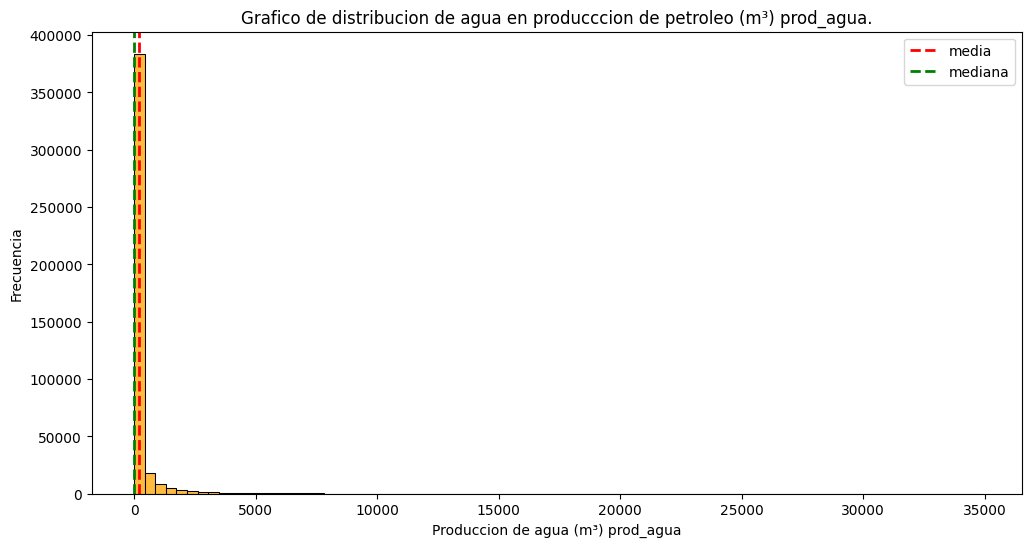

In [119]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, bins=80, color='orange', x =col)
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label='media')
plt.axvline(mediana, color='green', linestyle='dashed', linewidth=2, label='mediana')
plt.title(f'Grafico de distribucion de agua en producccion de petroleo (m³) {col}.')
plt.xlabel(F'Produccion de agua (m³) {col}')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

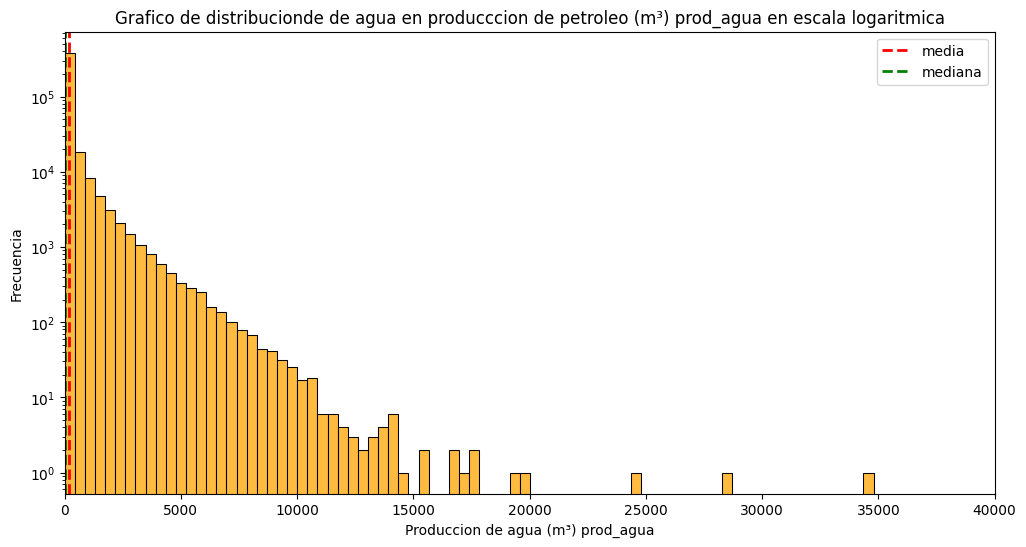

In [120]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, bins=80, color='orange', x =col)
plt.yscale('log')
plt.xlim(0, 40000)
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label='media')
plt.axvline(mediana, color='green', linestyle='dashed', linewidth=2, label='mediana')
plt.title(f'Grafico de distribucionde de agua en producccion de petroleo (m³) {col} en escala logaritmica')
plt.xlabel(F'Produccion de agua (m³) {col}')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

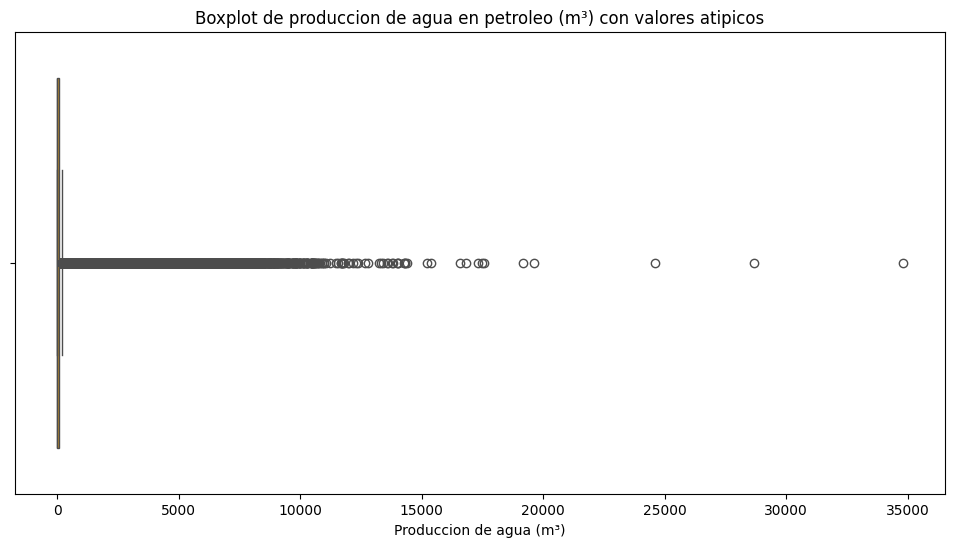

In [113]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, color='orange', x =col,)
plt.title('Boxplot de produccion de agua en petroleo (m³) con valores atipicos')
plt.xlabel('Produccion de agua (m³)')

plt.show()

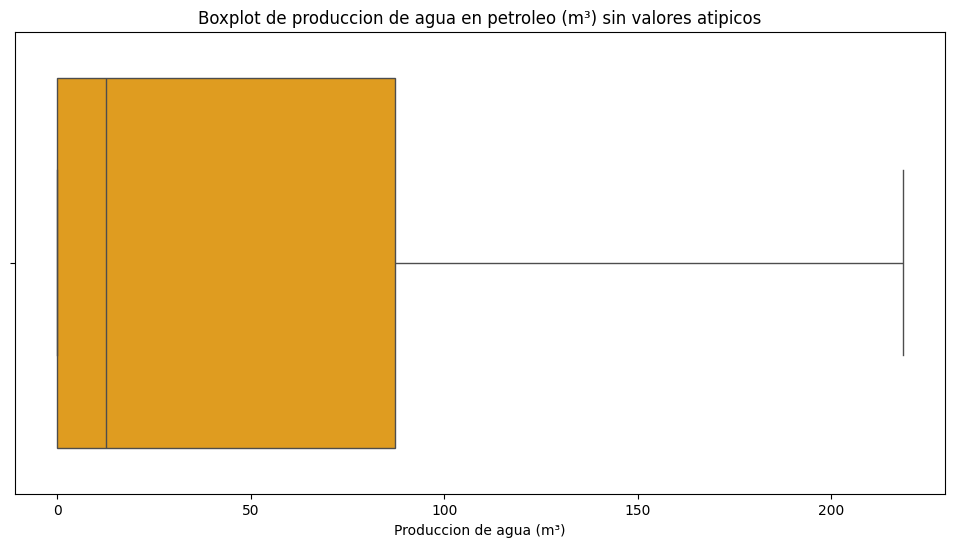

In [112]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, color='orange', x =col, showfliers=False)
plt.title('Boxplot de produccion de agua en petroleo (m³) sin valores atipicos')
plt.xlabel('Produccion de agua (m³)')

plt.show()

In [ ]:
#El dataset contiene 426.090 registros, cada uno correspondiente a la producción mensual de un pozo, abarcando un período de aproximadamente 20 años. La columna seleccionada para el análisis es prod_agua
#(producción de agua, en m³).El promedio es de 190,99 m³ y la mediana de 12,74 m³. Dado que el promedio es mayor que la mediana, la distribución presenta un sesgo positivo (cola hacia la derecha). En el primer
#gráfico se observa una barra de mayor altura que representa los pozos que no tienen producción o que producen muy poco. Los valores altos, en el extremo derecho del gráfico, son los que elevan el
#promedio y generan la cola hacia la derecha.El coeficiente de asimetría de 7,87 confirma un sesgo positivo extremo, generado por valores atípicos extremadamente altos. La curtosis de 113,48 indica colas
#extremadamente gruesas, con presencia de valores atípicos muy marcados, lo que se refleja en el histograma con escala logarítmica.

#El boxplot sin valores atípicos muestra que el rango dentro de la caja contiene valores muy cercanos a cero o muy bajos, y que ese rango conforma el 50% central de los datos. El primer cuartil (Q1) es 0 m³,
#lo que indica que el 25% inferior de los registros de prod_agua tiene producción nula.

